# Walkthrough: detecting crashes in dashcam clips

This notebook tells the story of the solution in order: what the data looks like, why the obvious approach failed, which signals actually work, and how the final submission is assembled. Every number here is computed live from the repo or the competition data.

| Section | Needs |
|---|---|
| 1. The data and its hidden structure | competition data |
| 2. Why supervised models collapse | competition data + feature caches |
| 3. The temporal signature of a crash | competition data |
| 4. From 0.54 to 0.79 | nothing (committed CSVs) |
| 5. Why physics earns a place in the blend | nothing |
| 6. Pseudo-labels: only as good as the teacher | nothing |
| 7. Rebuilding the final submission | nothing |
| 8. Choosing the final three | nothing |

Cells that need data you don't have print a note and are skipped. The saved outputs show what they produce. Raw frames are deliberately not shown, because competition data cannot be redistributed.

In [1]:
import os, sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from config import DATA_DIR, CACHE_DIR, SUBMISSIONS_DIR

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import rankdata, spearmanr
from sklearn.metrics import roc_auc_score

HAVE_DATA = os.path.isdir(os.path.join(DATA_DIR, "train"))
HAVE_CACHE = os.path.exists(os.path.join(CACHE_DIR, "cache_clip_features.npz"))

BLUE, ORANGE, INK, INK2, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#e6e5e0"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "axes.axisbelow": True, "axes.titlelocation": "left",
    "axes.titleweight": "bold", "axes.titlecolor": INK,
})
print("competition data:", "found" if HAVE_DATA else "not found, data cells will be skipped")
print("feature caches:  ", "found" if HAVE_CACHE else "not found, cache cells will be skipped")

competition data: found
feature caches:   found


## 1. The data and its hidden structure

Each clip is 30 JPEG frames at 384×224. There are 3,000 labelled training clips and 1,750 test clips. The interesting part is `group_id`.

In [2]:
if HAVE_DATA:
    train = pd.read_csv(os.path.join(DATA_DIR, "train_labels.csv"))
    n_test = len(pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv")))
    sizes = train.groupby("group_id").size()
    mix = train.groupby("group_id")["label"].agg(["sum", "size"])
    print(f"train clips: {len(train)}   test clips: {n_test}")
    print(f"groups: {train.group_id.nunique()}   clips per group: {sorted(int(s) for s in sizes.unique())}")
    print(f"groups with exactly one crash + one normal clip: {((mix['sum'] == 1) & (mix['size'] == 2)).mean():.0%}")
else:
    print("skipped: needs competition data")

train clips: 3000   test clips: 1750
groups: 1500   clips per group: [2]
groups with exactly one crash + one normal clip: 100%


**Every group is a matched pair: one crash clip and one normal clip cut from the same video,** the normal one from just before the crash. A model can score perfectly on train by telling the two halves of each pair apart, using the same road, the same car and the same lighting, without learning what a crash is. The test set's normal clips come from unrelated videos.

## 2. Why supervised models collapse

The first submission, an EfficientNet-B3 + GRU with 5-fold `GroupKFold`, scored **0.995 CV AUC and 0.538 on the leaderboard.** `GroupKFold` keeps each pair inside one fold, so this isn't simple leakage. The model learned a pair-relative shortcut that test clips don't share.

The check below makes that measurable:

1. Fit a simple probe (logistic regression on cached CLIP + motion features) with grouped CV.
2. Find visually matched clips using tiny grayscale thumbnails and mutual nearest neighbours.
3. Compare how the probe's scores correlate *within* matched pairs on train versus test.

In [3]:
def thumbnails(clip_dirs):
    out = np.zeros((len(clip_dirs), 3 * 48 * 28), np.float32)
    for j, d in enumerate(clip_dirs):
        out[j] = np.concatenate([
            np.asarray(Image.open(os.path.join(d, f"frame_{i:03d}.jpg")).convert("L").resize((48, 28), Image.BOX),
                       np.float32).ravel() for i in (0, 15, 29)])
    x = out.reshape(len(out), 3, -1)
    x = x - x.mean(2, keepdims=True)
    x /= np.linalg.norm(x, axis=2, keepdims=True) + 1e-6
    return x.reshape(len(out), -1) / np.sqrt(3)


def mutual_pairs(emb):
    sim = emb @ emb.T
    np.fill_diagonal(sim, -9)
    nn = sim.argmax(1)
    a = np.where(nn[nn] == np.arange(len(emb)))[0]
    return a[a < nn[a]], nn


if HAVE_DATA and HAVE_CACHE:
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import GroupKFold
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler

    test_ids = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv")).clip_id
    clip = np.load(os.path.join(CACHE_DIR, "cache_clip_features.npz"))
    motion = np.load(os.path.join(CACHE_DIR, "cache_motion_features.npz"))
    X_tr = np.hstack([clip["X_train"], motion["X_train"]])
    X_te = np.hstack([clip["X_test"], motion["X_test"]])
    y, groups = train.label.values, train.group_id.values

    def probe():
        return make_pipeline(StandardScaler(), LogisticRegression(C=0.01, max_iter=2000))

    oof = np.zeros(len(y))
    for tr, va in GroupKFold(5).split(X_tr, y, groups):
        oof[va] = probe().fit(X_tr[tr], y[tr]).predict_proba(X_tr[va])[:, 1]
    test_pred = probe().fit(X_tr, y).predict_proba(X_te)[:, 1]
    print(f"grouped 5-fold CV AUC of the probe: {roc_auc_score(y, oof):.3f}")

    th_tr = thumbnails([os.path.join(DATA_DIR, "train", c) for c in train.clip_id])
    th_te = thumbnails([os.path.join(DATA_DIR, "test", c) for c in test_ids])
    a_tr, nn_tr = mutual_pairs(th_tr)
    a_te, nn_te = mutual_pairs(th_te)
    precision = (groups[a_tr] == groups[nn_tr[a_tr]]).mean()
    print(f"thumbnail matching recovers the true train pair: {precision:.1%} precision ({len(a_tr)} pairs)")
    rho_tr = spearmanr(oof[a_tr], oof[nn_tr[a_tr]]).correlation
    rho_te = spearmanr(test_pred[a_te], test_pred[nn_te[a_te]]).correlation
    print(f"within-pair score correlation   train: {rho_tr:+.2f}   test: {rho_te:+.2f}  ({len(a_te)} test pairs)")
else:
    print("skipped: needs competition data and feature caches (cache_clip_features.npz, cache_motion_features.npz)")

grouped 5-fold CV AUC of the probe: 0.991


thumbnail matching recovers the true train pair: 92.6% precision (824 pairs)
within-pair score correlation   train: -0.58   test: +0.38  (298 test pairs)


On train, matched clips have **opposite** labels, so a good model scores them in opposite directions (negative correlation). On test, matched clips score in the **same** direction, so look-alike test clips mostly share a label. The structure the supervised model exploited does not exist at test time.

This rules out three tempting ideas:
- training end-to-end on train labels;
- trusting grouped CV as a validation set;
- smoothing or adjusting test scores using look-alike neighbours (V26 tried this and dropped 0.026).

It also refutes the early "sunny train / night test" theory. Mean frame brightness is about 111 on train versus 107 on test.

## 3. The temporal signature of a crash

Rather than *what* is in a frame, look at *how the clip changes over time*. Below is the mean absolute frame-to-frame difference, a crude motion energy measure, over 150 matched train pairs.

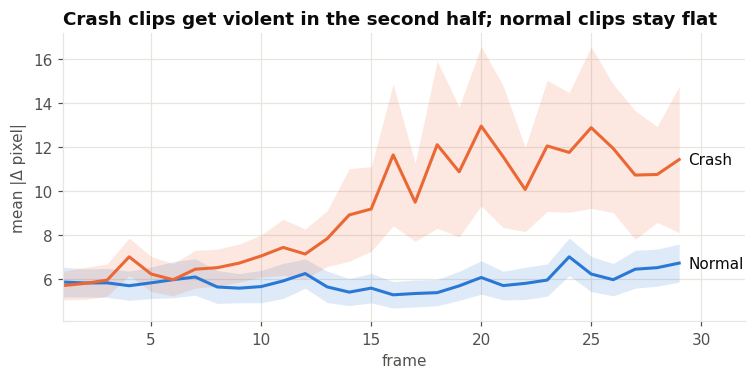

AUC of a single feature, peak motion in frames 15-29: 0.655


In [4]:
def motion_curve(clip_dir):
    frames = [np.asarray(Image.open(os.path.join(clip_dir, f"frame_{i:03d}.jpg")).convert("L").resize((96, 56)),
                         np.float32) for i in range(30)]
    return np.array([np.abs(frames[i + 1] - frames[i]).mean() for i in range(29)])


if HAVE_DATA:
    sample = train[train.group_id.isin(train.group_id.drop_duplicates().iloc[:150])]
    curves = np.array([motion_curve(os.path.join(DATA_DIR, "train", c)) for c in sample.clip_id])
    is_crash = sample.label.values == 1

    fig, ax = plt.subplots(figsize=(8, 3.4))
    t = np.arange(1, 30)
    for mask, color, name in [(~is_crash, BLUE, "Normal"), (is_crash, ORANGE, "Crash")]:
        m = curves[mask].mean(0)
        se = curves[mask].std(0) / np.sqrt(mask.sum())
        ax.fill_between(t, m - 1.96 * se, m + 1.96 * se, color=color, alpha=0.15, linewidth=0)
        ax.plot(t, m, color=color, linewidth=2)
        ax.annotate(name, (t[-1], m[-1]), xytext=(6, 0), textcoords="offset points", color=INK, va="center")
    ax.set(xlabel="frame", ylabel="mean |Δ pixel|", xlim=(1, 32))
    ax.set_title("Crash clips get violent in the second half; normal clips stay flat")
    plt.show()

    late_peak = curves[:, 14:].max(1)
    print(f"AUC of a single feature, peak motion in frames 15-29: {roc_auc_score(is_crash, late_peak):.3f}")
else:
    print("skipped: needs competition data")

Even this one hand-made feature separates crashes better than the supervised CNN did on test. The final pipeline uses the same idea with much better signals:

- **Zero-shot semantics over time (V18, V20).** Each of the 30 frames is scored against crash and normal-driving text prompts by SigLIP, EVA02 and CLIP, then summarised as *late spike*, *gradient* and *late minus early*. A crash is a jump in crash similarity, not a high average.
- **Physics (V7, V9, V16).** YOLOv8 tracks vehicles to measure box expansion (time to collision), deceleration and overlap, and vehicle-masked optical flow measures ego-camera shake.

## 4. From 0.54 to 0.79

In [5]:
lb = pd.read_csv(os.path.join(SUBMISSIONS_DIR, "leaderboard.csv"), parse_dates=["submitted_utc"])
milestones = {
    "submission_v1_effnet_gru.csv": "Supervised EfficientNet-B3 + GRU",
    "submission_zero_shot_final.csv": "Zero-shot CLIP prompts, no training",
    "submission_v7_yolo.csv": "+ YOLO kinematics",
    "submission_v18_ultimate.csv": "3 backbones x 30 frames, temporal features",
    "submission_v20_highres.csv": "same at 378 px",
    "submission_v21_transductive.csv": "+ physics LightGBM on test pseudo-labels",
    "submission_v24_feature_blender.csv": "LightGBM over 48 features",
    "submission_v27b_physics_injection.csv": "final rank blend",
}
steps = lb[lb.file.isin(milestones)].assign(step=lambda d: d.file.map(milestones))
steps["gain"] = steps.public_auc.diff()
steps[["submitted_utc", "step", "public_auc", "gain"]].style.format(
    {"public_auc": "{:.5f}", "gain": "{:+.3f}", "submitted_utc": "{:%b %d}"}, na_rep="").hide(axis="index")

submitted_utc,step,public_auc,gain
Sep 22,Supervised EfficientNet-B3 + GRU,0.53770,
Sep 23,"Zero-shot CLIP prompts, no training",0.67702,+0.139
Sep 26,+ YOLO kinematics,0.73669,+0.060
Oct 03,"3 backbones x 30 frames, temporal features",0.76349,+0.027
Oct 03,same at 378 px,0.78547,+0.022
Oct 04,+ physics LightGBM on test pseudo-labels,0.78826,+0.003
Oct 04,LightGBM over 48 features,0.78943,+0.001
Oct 05,final rank blend,0.79098,+0.002


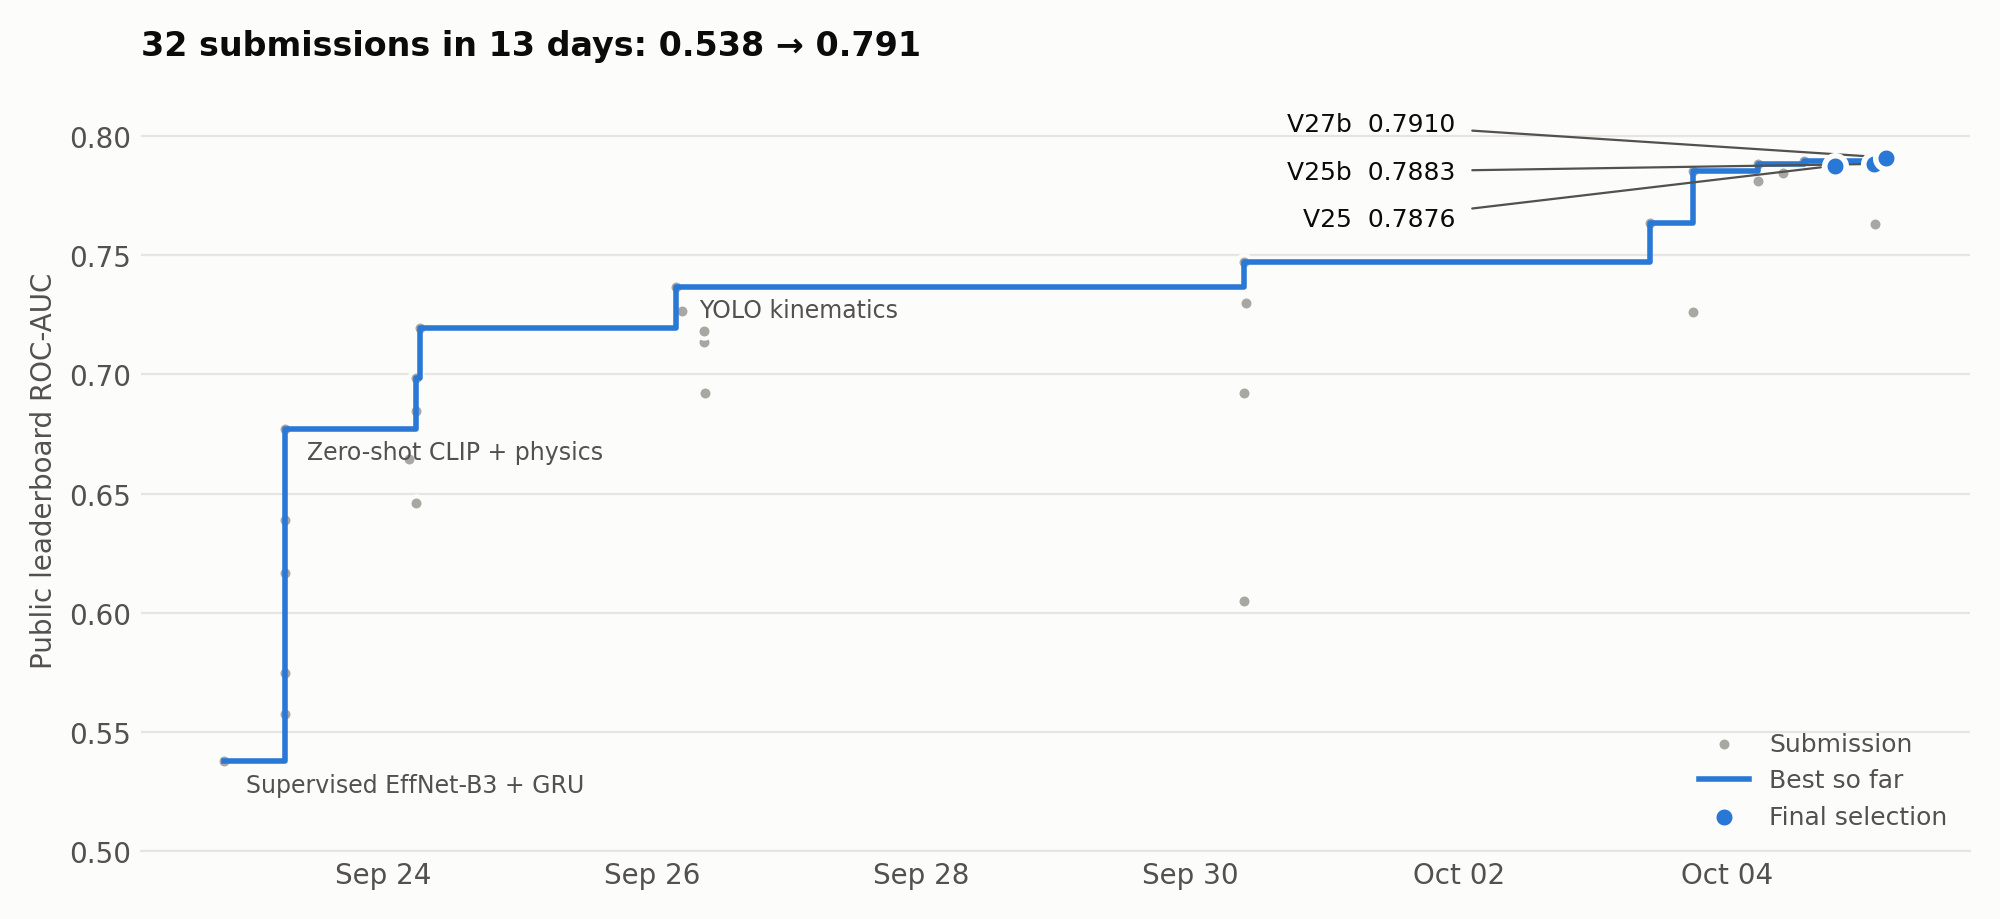

In [6]:
from IPython.display import Image as Show
Show(filename=str(ROOT / "assets" / "leaderboard_light.png"), width=900)

## 5. Why physics earns a place in the blend

A blend component helps when it is **good and different**. Rank correlations between the main components:

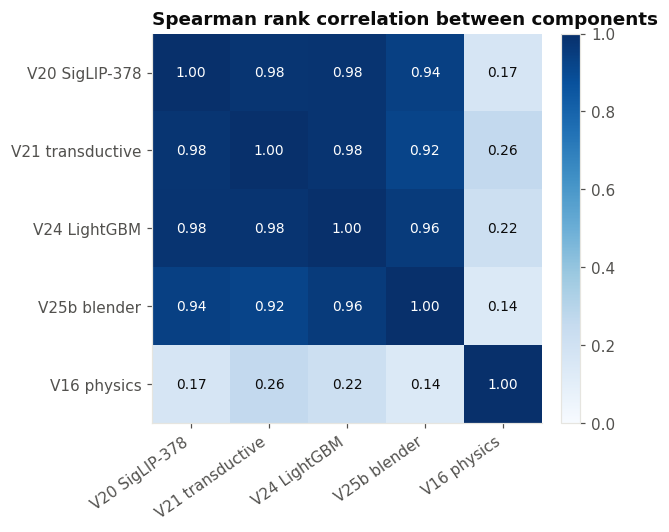

In [7]:
names = {"V20 SigLIP-378": "v20_highres", "V21 transductive": "v21_transductive", "V24 LightGBM": "v24_feature_blender",
         "V25b blender": "v25b_final_blend", "V16 physics": "v16_advanced_physics"}
S = pd.DataFrame({k: pd.read_csv(os.path.join(SUBMISSIONS_DIR, f"submission_{v}.csv")).label for k, v in names.items()})
corr = S.corr("spearman")

fig, ax = plt.subplots(figsize=(5.6, 4.6))
im = ax.imshow(corr, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=35, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iat[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="white" if v > 0.6 else INK, fontsize=9)
ax.set_title("Spearman rank correlation between components")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

The vision models are highly redundant (ρ 0.92–0.98 with each other). The pure-physics V16 scorer (ρ ≈ 0.22 with V24) sees different evidence: tracking and deceleration rather than appearance. That is why an 8% dose of it is the final step.

## 6. Pseudo-labels: only as good as the teacher

Training on the test set's own confident predictions (transductive learning) let the blenders learn on the test distribution. It only worked once the teacher was strong:

In [8]:
auc = lb.set_index("file").public_auc
pairs = [("submission_v4.csv", "submission_v5_pseudo.csv", "V5: self-training"),
         ("submission_v20_highres.csv", "submission_v21_transductive.csv", "V21: physics LightGBM")]
pd.DataFrame([{"student": s, "teacher AUC": auc[t], "student AUC": auc[st], "gain": auc[st] - auc[t]}
              for t, st, s in pairs]).style.format(
    {"teacher AUC": "{:.3f}", "student AUC": "{:.3f}", "gain": "{:+.3f}"}).hide(axis="index")

student,teacher AUC,student AUC,gain
V5: self-training,0.684,0.646,-0.039
V21: physics LightGBM,0.785,0.788,+0.003


## 7. Rebuilding the final submission

V27b is a rank blend of three committed submissions. Rebuilding it here and comparing with what was submitted:

In [9]:
def rank_normalize(x):
    return np.argsort(np.argsort(x)).astype(float) / (len(x) - 1)


def load(name):
    return pd.read_csv(os.path.join(SUBMISSIONS_DIR, f"submission_{name}.csv"))


v24, v16, v25b = (load(n).label.values for n in ["v24_feature_blender", "v16_advanced_physics", "v25b_final_blend"])
final = rank_normalize(0.85 * rank_normalize(v24) + 0.08 * rank_normalize(v16) + 0.07 * rank_normalize(v25b))

submitted = load("v27b_physics_injection")
print(f"rows: {len(final)}   max |rebuilt - submitted|: {np.abs(final - submitted.label.values).max():.1e}"
      "   (the CSV stores 6 decimals)")
print(f"rank agreement: {spearmanr(final, submitted.label).correlation:.6f}")

rows: 1750   max |rebuilt - submitted|: 5.0e-07   (the CSV stores 6 decimals)
rank agreement: 1.000000


For the full chain, re-running the LightGBM blenders V24 and V25b from cached features, use `python tools/verify_pipeline.py --full`. It reproduces all three files exactly.

## 8. Choosing the final three

The public leaderboard scores about 525 clips, so scores within ~0.003 are statistically tied. Kaggle typically keeps the best of your selected submissions on the private split, so the picks should be **near-best and mutually different**:

In [10]:
cands = {"V27b": "v27b_physics_injection", "V28": "v28_final", "V24": "v24_feature_blender",
         "V25b": "v25b_final_blend", "V25": "v25_standalone"}
ref = load("v27b_physics_injection").label
rows = [{"submission": k, "public AUC": auc[f"submission_{v}.csv"],
         "rho vs V27b": spearmanr(load(v).label, ref).correlation,
         "selected": "yes" if k in ("V27b", "V25b", "V25") else ""} for k, v in cands.items()]
pd.DataFrame(rows).style.format({"public AUC": "{:.5f}", "rho vs V27b": "{:.3f}"}).hide(axis="index")

submission,public AUC,rho vs V27b,selected
V27b,0.79098,1.000,yes
V28,0.79022,0.999,
V24,0.78943,0.997,
V25b,0.78829,0.953,yes
V25,0.78755,0.903,yes


V28 and V24 are near-copies of V27b (ρ ≥ 0.997) and add almost no independent chance. V25b and V25 are nearly as good on public and genuinely different.

## What didn't work, and where to go next

The full list with measurements is in [docs/FINDINGS.md](../docs/FINDINGS.md): semantic velocity, manifold smoothing, cleaned-train supervision, blending everything, a Qwen2.5-VL zero-shot pass and a pair-difference adjustment.

To run the pipeline yourself, see [pipeline/README.md](../pipeline/README.md).